# SPMS LSTM Forecast Risk Experimental Report

This notebook explores and independently tests the forecast-risk branch built from the frozen LSTM Autoencoder output. It does **not** retrain or modify the Autoencoder. The target is daily P95 reconstruction MAE conditional on the PMA Granulator operating on the target date.

Day+1 and Day+7 are release candidates. Day+14 is research-only. Day+30 is deferred. Runtime release requires both candidates to beat persistence and weekly-naive baselines with test MASE below 1.0.

## 1. Setup And Artifact Paths

In [1]:
from pathlib import Path
import hashlib
import json
import os
import sys
import warnings

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_DETERMINISTIC_OPS", "1")
warnings.filterwarnings("ignore", category=FutureWarning)

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def find_capstone_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Data").exists() and (candidate / "project").exists():
            return candidate
    raise FileNotFoundError("Could not locate the Capstone workspace root.")

CAPSTONE_ROOT = find_capstone_root(Path.cwd().resolve())
if str(CAPSTONE_ROOT) not in sys.path:
    sys.path.insert(0, str(CAPSTONE_ROOT))

from Data.forecast_pipeline import (
    FEATURE_COLUMNS, HORIZONS, LOOKBACK_DAYS, RELEASED_HORIZONS,
    build_daily_history, build_sequences, evaluate, set_deterministic_seed,
)

DATA_DIR = CAPSTONE_ROOT / "Data"
FORECAST_DIR = DATA_DIR / "export_models" / "forecast"
WINDOW_METADATA_PATH = DATA_DIR / "data" / "spms_valid_windows_metadata.csv"
UPSTREAM_METADATA_PATH = DATA_DIR / "export_models" / "spms_lstm_rebuild_metadata.json"
HISTORY_PATH = FORECAST_DIR / "spms_daily_health_history.csv"
MODEL_PATH = FORECAST_DIR / "spms_daily_p95_forecast.keras"
SCALER_PATH = FORECAST_DIR / "spms_daily_p95_forecast_scalers.joblib"
CALIBRATION_PATH = FORECAST_DIR / "spms_daily_p95_forecast_calibration.joblib"
METADATA_PATH = FORECAST_DIR / "spms_daily_p95_forecast_metadata.json"
GATE_PATH = FORECAST_DIR / "spms_daily_p95_deployment_gate.json"

required_paths = [WINDOW_METADATA_PATH, UPSTREAM_METADATA_PATH, HISTORY_PATH, MODEL_PATH, SCALER_PATH, CALIBRATION_PATH, METADATA_PATH, GATE_PATH]
missing_paths = [str(path) for path in required_paths if not path.exists()]
assert not missing_paths, f"Missing required artifacts: {missing_paths}"

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")
plt.style.use("seaborn-v0_8-whitegrid")
set_deterministic_seed(42)
display(Markdown(f"**Workspace:** `{CAPSTONE_ROOT}`  \n**Forecast artifacts:** `{FORECAST_DIR}`"))

**Workspace:** `C:\Users\filbe\OneDrive\Documents\President University\Capstone`  
**Forecast artifacts:** `C:\Users\filbe\OneDrive\Documents\President University\Capstone\Data\export_models\forecast`

## 2. Frozen Autoencoder Window Metadata Overview

Each source row is already a complete, active-running, one-minute-continuous 15-minute Autoencoder window that does not cross batch or process boundaries.

In [2]:
windows = pd.read_csv(WINDOW_METADATA_PATH)
windows["start_timestamp"] = pd.to_datetime(windows["start_timestamp"])
windows["end_timestamp"] = pd.to_datetime(windows["end_timestamp"])
windows["reconstruction_error"] = pd.to_numeric(windows["reconstruction_error"])
upstream_metadata = json.loads(UPSTREAM_METADATA_PATH.read_text(encoding="utf-8"))
threshold = float(upstream_metadata["threshold"])

window_summary = pd.DataFrame({
    "metric": ["valid windows", "first window", "last window", "window size", "model features", "anomaly threshold", "threshold policy", "skipped candidate windows"],
    "value": [f"{len(windows):,}", windows["start_timestamp"].min(), windows["end_timestamp"].max(), upstream_metadata["window_size"], len(upstream_metadata["features"]), threshold, upstream_metadata["threshold_policy"], f"{upstream_metadata['skipped_window_count']:,}"],
})
display(window_summary)

split_window_summary = windows.groupby("split").agg(
    windows=("window_id", "size"), first_end=("end_timestamp", "min"), last_end=("end_timestamp", "max"),
    mean_mae=("reconstruction_error", "mean"), p95_mae=("reconstruction_error", lambda values: np.quantile(values, 0.95)),
    max_mae=("reconstruction_error", "max"),
)
display(split_window_summary)

,metric,value
0,valid windows,"4,963"
1,first window,2025-05-30 21:26:00
2,last window,2026-03-13 00:46:00
3,window size,15
4,model features,8
5,anomaly threshold,0.224178
6,threshold policy,99th percentile of validation reconstruction MAE
7,skipped candidate windows,"409,729"


,windows,first_end,last_end,mean_mae,p95_mae,max_mae
split,,,,,,
test,734,2026-02-20 15:14:00,2026-03-13 00:46:00,0.118937,0.226613,0.271724
train,3483,2025-05-30 21:40:00,2025-11-06 22:59:00,0.034170,0.079463,0.130502
validation,746,2025-11-07 22:46:00,2026-02-20 14:59:00,0.049343,0.127706,0.252121


## 3. Daily P95 Target And Calendar Coverage

Valid windows are aggregated by calendar day. Missing operating days remain explicit rows instead of being compressed away. The observation flag separates missing calendar days from measured reconstruction errors.

In [3]:
daily = build_daily_history(windows)
exported_daily = pd.read_csv(HISTORY_PATH, parse_dates=["date"])
comparison_columns = ["date", "p95_reconstruction_error", "mean_reconstruction_error", "max_reconstruction_error", "window_count", "observation_flag"]
pd.testing.assert_frame_equal(
    daily[comparison_columns].reset_index(drop=True), exported_daily[comparison_columns].reset_index(drop=True),
    check_dtype=False, check_exact=False, rtol=1e-9, atol=1e-9,
)

daily_summary = pd.DataFrame({
    "metric": ["calendar start", "calendar end", "calendar days", "observed operating days", "missing calendar days", "observation coverage"],
    "value": [daily["date"].min().date(), daily["date"].max().date(), len(daily), int(daily["observation_flag"].sum()), int((daily["observation_flag"] == 0).sum()), f"{daily['observation_flag'].mean():.1%}"],
})
display(daily_summary)
display(daily.head(10))
print("Exported daily history exactly matches independent aggregation: PASS")

,metric,value
0,calendar start,2025-05-30
1,calendar end,2026-03-13
2,calendar days,288
3,observed operating days,170
4,missing calendar days,118
5,observation coverage,59.0%


,date,p95_reconstruction_error,mean_reconstruction_error,max_reconstruction_error,window_count,split,observation_flag,days_since_operation,weekday_sin,weekday_cos
0,2025-05-30,0.067306,0.051255,0.068750,11,train,1,0,-0.433884,-0.900969
1,2025-05-31,0.059673,0.019384,0.067101,44,train,1,0,-0.974928,-0.222521
2,2025-06-01,NaN,NaN,NaN,0,NaN,0,1,-0.781831,0.623490
3,2025-06-02,0.071664,0.053912,0.078538,8,train,1,0,0.000000,1.000000
4,2025-06-03,0.066733,0.038129,0.066908,39,train,1,0,0.781831,0.623490
5,2025-06-04,0.069657,0.033338,0.085084,48,train,1,0,0.974928,-0.222521
6,2025-06-05,0.073079,0.044929,0.095015,53,train,1,0,0.433884,-0.900969
7,2025-06-06,NaN,NaN,NaN,0,NaN,0,1,-0.433884,-0.900969
8,2025-06-07,0.055966,0.027862,0.077458,26,train,1,0,-0.974928,-0.222521
9,2025-06-08,NaN,NaN,NaN,0,NaN,0,1,-0.781831,0.623490


Exported daily history exactly matches independent aggregation: PASS


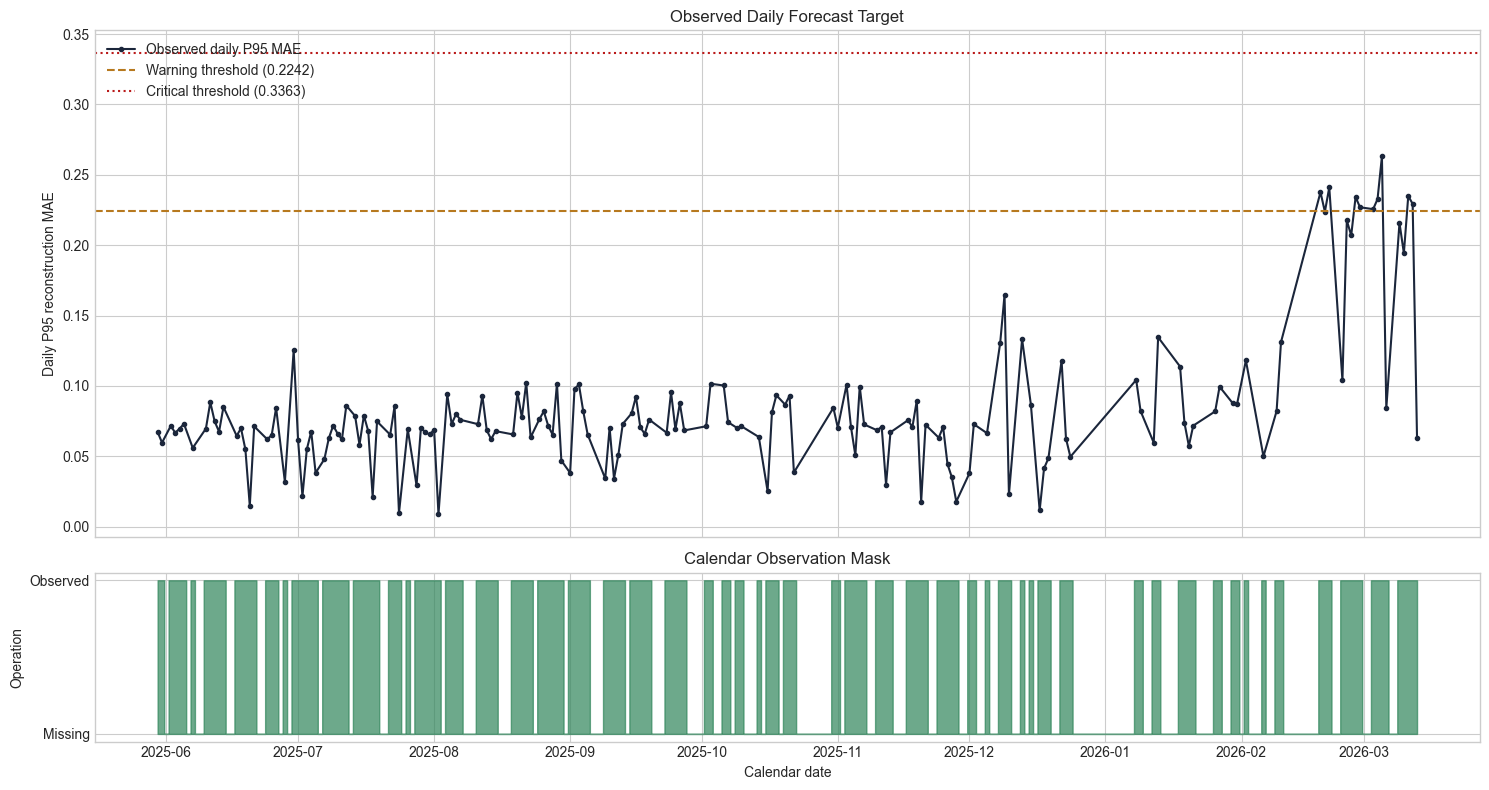

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
observed = daily[daily["observation_flag"].eq(1)]
axes[0].plot(observed["date"], observed["p95_reconstruction_error"], color="#1b263b", linewidth=1.5, marker="o", markersize=3, label="Observed daily P95 MAE")
axes[0].axhline(threshold, color="#b7791f", linestyle="--", label=f"Warning threshold ({threshold:.4f})")
axes[0].axhline(threshold * 1.5, color="#ba1a1a", linestyle=":", label=f"Critical threshold ({threshold * 1.5:.4f})")
axes[0].set_ylabel("Daily P95 reconstruction MAE")
axes[0].set_title("Observed Daily Forecast Target")
axes[0].legend(loc="upper left")
axes[1].fill_between(daily["date"], 0, daily["observation_flag"], step="mid", color="#2f855a", alpha=0.7)
axes[1].set_yticks([0, 1], labels=["Missing", "Observed"])
axes[1].set_ylabel("Operation")
axes[1].set_xlabel("Calendar date")
axes[1].set_title("Calendar Observation Mask")
plt.tight_layout()
plt.show()

## 4. Forecast Feature Policy

The compact LSTM receives a 28-day calendar sequence. Missing daily target statistics become zero only after a separate observation flag is retained, so zero is not interpreted as an observed score.

In [5]:
feature_descriptions = {
    "p95_reconstruction_error": "Daily 95th percentile Autoencoder reconstruction MAE and forecast target history.",
    "mean_reconstruction_error": "Daily mean reconstruction MAE.",
    "max_reconstruction_error": "Daily maximum reconstruction MAE.",
    "window_count": "Number of valid 15-minute windows observed that day.",
    "observation_flag": "1 when valid operating windows exist; 0 for a missing calendar day.",
    "days_since_operation": "Calendar days since the latest observed operating day.",
    "weekday_sin": "Cyclic weekday encoding.",
    "weekday_cos": "Cyclic weekday encoding.",
    "horizon_fraction": "Requested horizon divided by the maximum research horizon (14).",
}
display(pd.DataFrame([{"feature": feature, "description": feature_descriptions[feature]} for feature in FEATURE_COLUMNS]))
print(f"Lookback: {LOOKBACK_DAYS} calendar days | Horizons: {HORIZONS} | Runtime candidates: {RELEASED_HORIZONS}")

,feature,description
0,p95_reconstruction_error,Daily 95th percentile Autoencoder reconstructi...
1,mean_reconstruction_error,Daily mean reconstruction MAE.
2,max_reconstruction_error,Daily maximum reconstruction MAE.
3,window_count,Number of valid 15-minute windows observed tha...
4,observation_flag,1 when valid operating windows exist; 0 for a ...
5,days_since_operation,Calendar days since the latest observed operat...
6,weekday_sin,Cyclic weekday encoding.
7,weekday_cos,Cyclic weekday encoding.
8,horizon_fraction,Requested horizon divided by the maximum resea...


Lookback: 28 calendar days | Horizons: (1, 7, 14) | Runtime candidates: (1, 7)


## 5. Exact Calendar-Horizon Sequence Tests

Every target date must be exactly the requested number of calendar days after its anchor. Targets are included only when the target date has observed operating windows.

In [6]:
samples = build_sequences(daily)
calendar_offsets = (samples.target_dates - samples.anchor_dates).astype("timedelta64[D]").astype(int)
np.testing.assert_array_equal(calendar_offsets, samples.horizons)
assert samples.x.shape[1] == LOOKBACK_DAYS
assert samples.x.shape[2] == len(FEATURE_COLUMNS)
assert set(np.unique(samples.horizons)) == set(HORIZONS)

sample_count_table = pd.DataFrame({"split": samples.splits, "horizon_days": samples.horizons}).groupby(["split", "horizon_days"]).size().unstack(fill_value=0)
display(sample_count_table)
print(f"Sequence tensor shape: {samples.x.shape}")
print("Exact calendar offsets: PASS")
print("Missing-day masks retained:", bool((samples.x[:, :, FEATURE_COLUMNS.index('observation_flag')] == 0).any()))

horizon_days,1,7,14
split,,,
test,16,16,16
train,88,84,78
validation,46,46,46


Sequence tensor shape: (436, 28, 9)
Exact calendar offsets: PASS
Missing-day masks retained: True


## 6. Artifact Reload And Prediction Smoke Test

The saved model, train-fitted scalers, residual calibration, metadata, and gate are loaded from disk. This verifies that the experiment is reproducible without retraining.

In [7]:
import keras

forecast_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
deployment_gate = json.loads(GATE_PATH.read_text(encoding="utf-8"))
scalers = joblib.load(SCALER_PATH)
calibration = joblib.load(CALIBRATION_PATH)
model = keras.models.load_model(MODEL_PATH, compile=False)

scaled_x = scalers["x_scaler"].transform(samples.x.reshape(-1, samples.x.shape[-1])).reshape(samples.x.shape)
scaled_predictions = model.predict(scaled_x, verbose=0).reshape(-1, 1)
predictions = scalers["y_scaler"].inverse_transform(scaled_predictions).reshape(-1)
assert np.isfinite(predictions).all()

artifact_status = pd.DataFrame([
    {"artifact": path.name, "exists": path.exists(), "size_bytes": path.stat().st_size, "sha256_prefix": hashlib.sha256(path.read_bytes()).hexdigest()[:16]}
    for path in [MODEL_PATH, SCALER_PATH, CALIBRATION_PATH, METADATA_PATH, HISTORY_PATH, GATE_PATH]
])
display(artifact_status)
print("Model input shape:", model.input_shape)
print("Prediction count:", len(predictions))
print("Finite artifact predictions: PASS")

,artifact,exists,size_bytes,sha256_prefix
0,spms_daily_p95_forecast.keras,True,56288,0d8c04991faf0525
1,spms_daily_p95_forecast_scalers.joblib,True,1081,c9ab8322baecae06
2,spms_daily_p95_forecast_calibration.joblib,True,104,bef2660018ed44ca
3,spms_daily_p95_forecast_metadata.json,True,7861,60c66e4d6901b0da
4,spms_daily_health_history.csv,True,24875,56d350ef2d9c2cfc
5,spms_daily_p95_deployment_gate.json,True,614,15f3ebae41a4b359


Model input shape: (None, 28, 9)
Prediction count: 436
Finite artifact predictions: PASS


## 7. Recomputed Chronological Evaluation

Evaluation is recomputed from the reloaded artifacts. MASE uses the mean absolute one-step change from observed training-day targets as its scale.

In [8]:
recomputed_evaluation, recomputed_calibration = evaluate(daily, samples, predictions, threshold=threshold)
metric_rows = []
for horizon in HORIZONS:
    for split in ("validation", "test"):
        payload = recomputed_evaluation[str(horizon)][split]
        for method in ("model", "persistence", "weekly_naive"):
            metrics = payload[method]
            metric_rows.append({
                "horizon_days": horizon, "split": split, "method": method, "samples": metrics["sample_count"],
                "mae": metrics["mae"], "rmse": metrics["rmse"], "mase": metrics["mase"],
                "interval_90_coverage": metrics.get("interval_90_coverage", np.nan),
            })
metrics_table = pd.DataFrame(metric_rows)
display(metrics_table)

for horizon in HORIZONS:
    for split in ("validation", "test"):
        for method in ("model", "persistence", "weekly_naive"):
            np.testing.assert_allclose(
                recomputed_evaluation[str(horizon)][split][method]["mae"],
                forecast_metadata["evaluation"][str(horizon)][split][method]["mae"],
                rtol=1e-5, atol=1e-7,
            )
print("Stored and independently recomputed MAE metrics match: PASS")

,horizon_days,split,method,samples,mae,rmse,mase,interval_90_coverage
0,1,validation,model,46,0.026122,0.037721,1.156453,0.891304
1,1,validation,persistence,46,0.035694,0.047267,1.580222,NaN
2,1,validation,weekly_naive,46,0.038186,0.049810,1.690517,NaN
3,1,test,model,16,0.133207,0.145951,5.897215,0.187500
4,1,test,persistence,16,0.056911,0.084132,2.519499,NaN
5,1,test,weekly_naive,16,0.056263,0.076682,2.490836,NaN
6,7,validation,model,46,0.026314,0.039313,1.164953,0.891304
7,7,validation,persistence,46,0.034740,0.043634,1.537983,NaN
8,7,validation,weekly_naive,46,0.034740,0.043634,1.537983,NaN
9,7,test,model,16,0.131689,0.144227,5.830005,0.187500


Stored and independently recomputed MAE metrics match: PASS


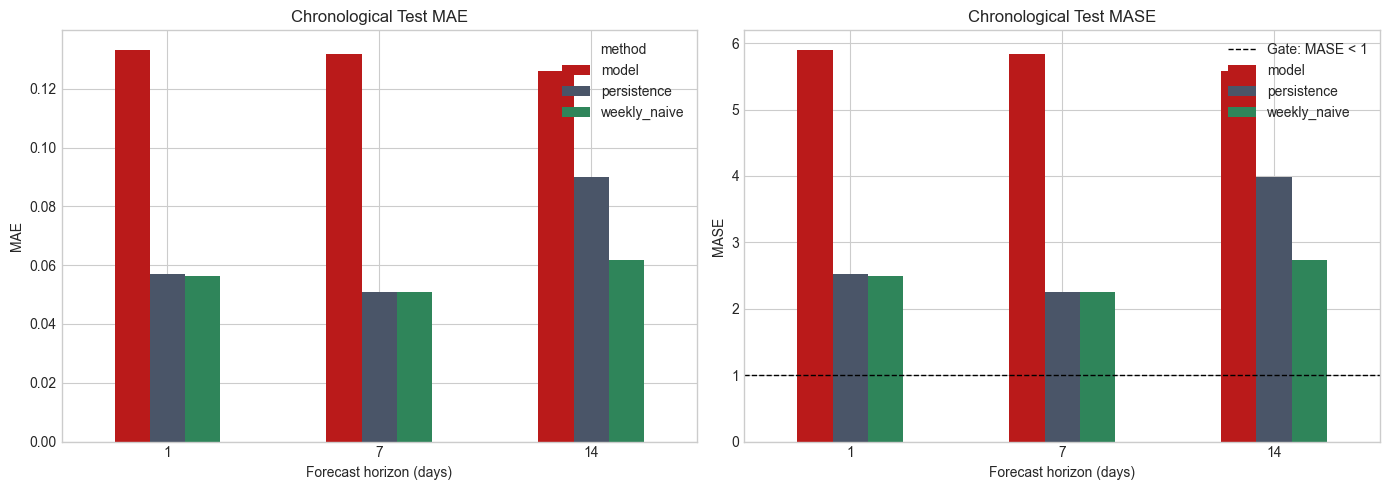

In [9]:
test_metrics = metrics_table[metrics_table["split"].eq("test")].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"model": "#ba1a1a", "persistence": "#4a5568", "weekly_naive": "#2f855a"}
for axis, metric in zip(axes, ["mae", "mase"]):
    pivot = test_metrics.pivot(index="horizon_days", columns="method", values=metric)
    pivot.plot(kind="bar", ax=axis, color=[colors[column] for column in pivot.columns])
    axis.set_title(f"Chronological Test {metric.upper()}")
    axis.set_xlabel("Forecast horizon (days)")
    axis.set_ylabel(metric.upper())
    axis.tick_params(axis="x", rotation=0)
    if metric == "mase":
        axis.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Gate: MASE < 1")
        axis.legend()
plt.tight_layout()
plt.show()

## 8. Test Forecasts And 90% Residual Intervals

Intervals use the 90th percentile of absolute validation residuals for each horizon. The plot exposes the chronological test distribution shift rather than hiding it.

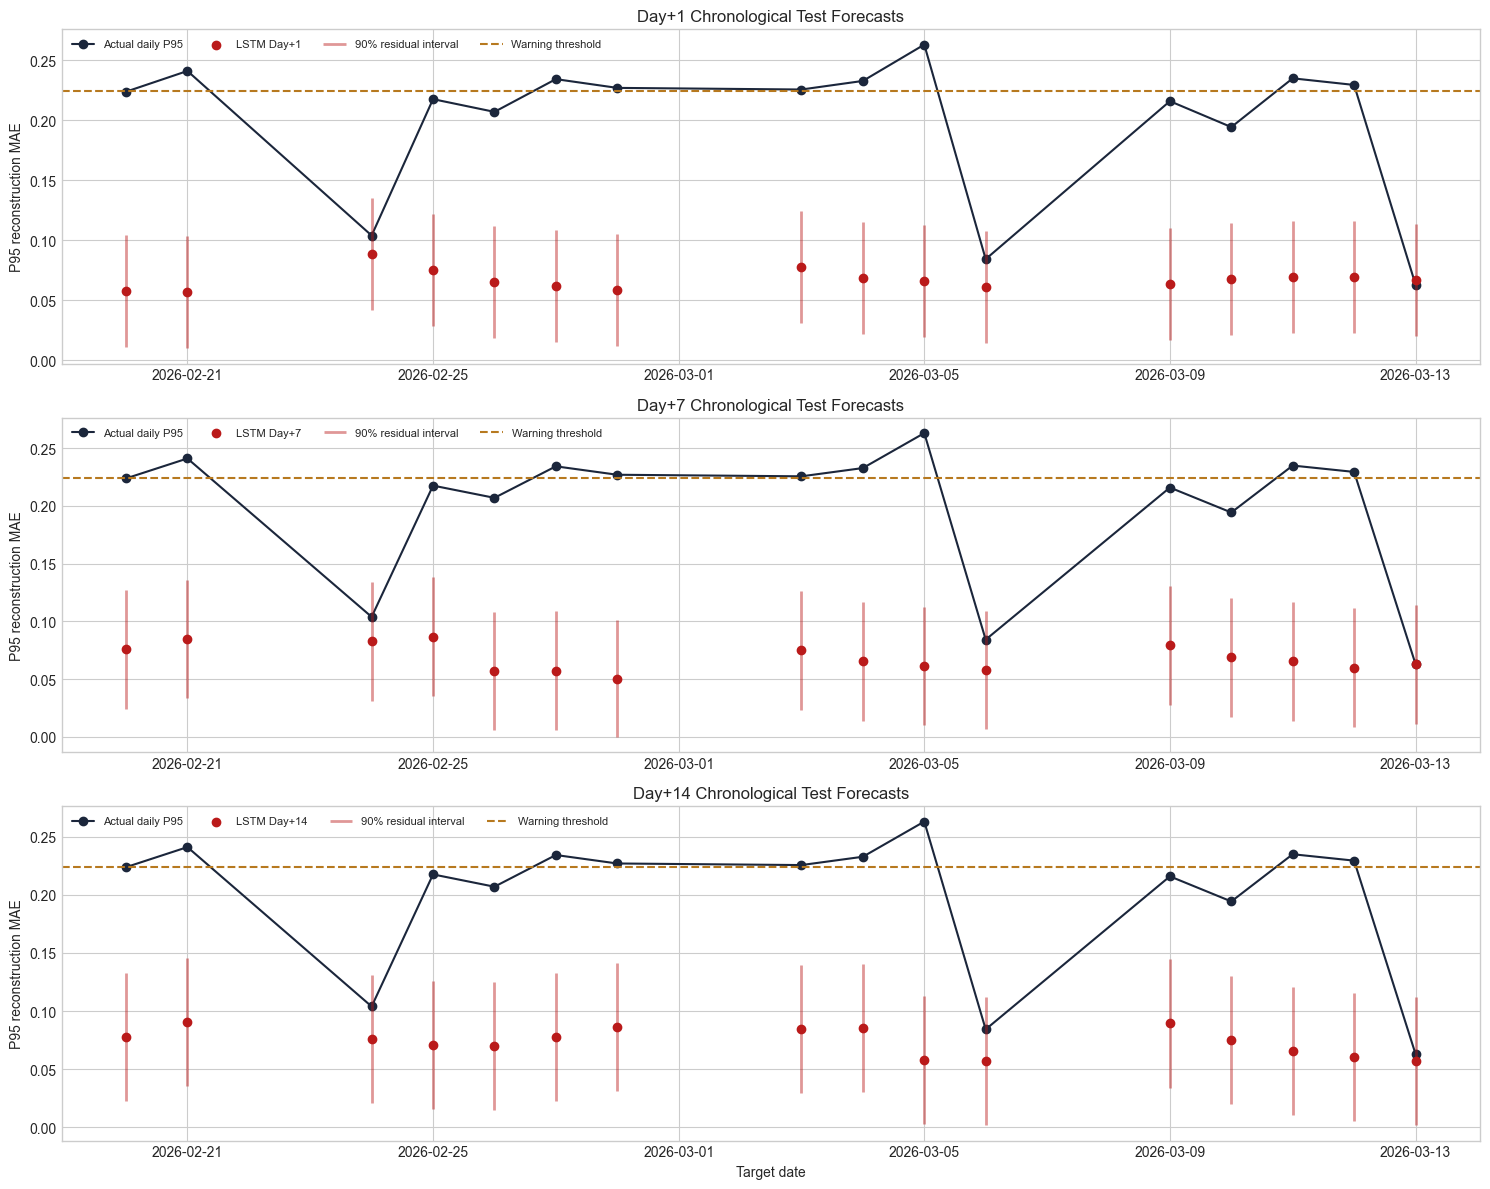

In [10]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(15, 12), sharex=False)
for axis, horizon in zip(axes, HORIZONS):
    mask = (samples.splits == "test") & (samples.horizons == horizon)
    dates = pd.to_datetime(samples.target_dates[mask])
    actual = samples.y[mask]
    predicted = predictions[mask]
    residual = float(recomputed_calibration[horizon])
    lower = np.maximum(0, predicted - residual)
    upper = predicted + residual
    axis.plot(dates, actual, marker="o", color="#1b263b", label="Actual daily P95")
    axis.scatter(dates, predicted, color="#ba1a1a", label=f"LSTM Day+{horizon}", zorder=3)
    axis.vlines(dates, lower, upper, color="#ba1a1a", alpha=0.45, linewidth=2, label="90% residual interval")
    axis.axhline(threshold, color="#b7791f", linestyle="--", label="Warning threshold")
    axis.set_title(f"Day+{horizon} Chronological Test Forecasts")
    axis.set_ylabel("P95 reconstruction MAE")
    axis.legend(loc="upper left", ncol=4, fontsize=8)
axes[-1].set_xlabel("Target date")
plt.tight_layout()
plt.show()

## 9. Deployment Gate Decision

The gate is deliberately strict. A model that fails either released horizon is not exposed as a usable forecast. The API returns HTTP 503 and the dashboard shows **Forecast model unavailable**.

In [11]:
gate_rows = []
for horizon in RELEASED_HORIZONS:
    item = deployment_gate["horizons"][str(horizon)]
    gate_rows.append({"horizon_days": horizon, "passed": item["passed"], **item["checks"]})
display(pd.DataFrame(gate_rows))

gate_label = "PASSED - runtime forecast may be exposed" if deployment_gate["passed"] else "FAILED - runtime must report model unavailable"
display(Markdown(f"### Deployment gate: **{gate_label}**"))
print(deployment_gate["primary_rule"])
assert deployment_gate["passed"] is False, "This report targets the currently rejected forecast artifact."

,horizon_days,passed,mase_below_one,beats_persistence_mae,beats_weekly_naive_mae
0,1,False,False,False,False
1,7,False,False,False,False


### Deployment gate: **FAILED - runtime must report model unavailable**

Test MASE < 1.0 and MAE beats persistence and weekly-naive for Day+1 and Day+7.


## 10. Latest Exploratory Forecast Values

These values demonstrate that the artifact can technically produce Day+1 and Day+7 outputs. They are for model inspection only. The application must suppress them because the deployment gate failed.

In [12]:
latest_anchor = daily["date"].max()
latest_sequence = daily.tail(LOOKBACK_DAYS).copy()
metric_columns = ["p95_reconstruction_error", "mean_reconstruction_error", "max_reconstruction_error"]
exploratory_rows = []
for horizon in RELEASED_HORIZONS:
    feature_frame = latest_sequence[metric_columns + ["window_count", "observation_flag", "days_since_operation", "weekday_sin", "weekday_cos"]].copy()
    feature_frame[metric_columns] = feature_frame[metric_columns].fillna(0.0)
    feature_frame["horizon_fraction"] = horizon / max(HORIZONS)
    sequence = feature_frame[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
    scaled = scalers["x_scaler"].transform(sequence).reshape(1, LOOKBACK_DAYS, len(FEATURE_COLUMNS))
    scaled_prediction = model.predict(scaled, verbose=0).reshape(-1, 1)
    predicted = float(scalers["y_scaler"].inverse_transform(scaled_prediction)[0, 0])
    residual = float(recomputed_calibration[horizon])
    exploratory_rows.append({
        "horizon": f"Day+{horizon}", "target_date": (latest_anchor + pd.Timedelta(days=horizon)).date(),
        "predicted_p95_mae": predicted, "lower_90": max(0.0, predicted - residual), "upper_90": predicted + residual,
        "threshold": threshold, "deployable": False,
    })
display(pd.DataFrame(exploratory_rows))
display(Markdown("**Interpretation:** technical artifact output only. The application correctly suppresses these values because the chronological gate failed."))

,horizon,target_date,predicted_p95_mae,lower_90,upper_90,threshold,deployable
0,Day+1,2026-03-14,0.065570,0.018890,0.112251,0.224178,False
1,Day+7,2026-03-20,0.066561,0.015125,0.117997,0.224178,False


**Interpretation:** technical artifact output only. The application correctly suppresses these values because the chronological gate failed.

## 11. Limitations And Scientific Claim Boundary

In [13]:
display(Markdown("\n".join(f"- {item}" for item in forecast_metadata["limitations"])))
threshold_crossing_rows = []
for horizon in HORIZONS:
    metrics = recomputed_evaluation[str(horizon)]["test"]["model"]
    threshold_crossing_rows.append({
        "horizon_days": horizon,
        "actual_threshold_crossings": metrics["actual_threshold_crossings"],
        "predicted_threshold_crossings": metrics["predicted_threshold_crossings"],
        "interval_crosses_threshold": metrics["interval_crosses_threshold"],
        "interval_90_coverage": metrics["interval_90_coverage"],
    })
display(pd.DataFrame(threshold_crossing_rows))

- Forecasts estimate daily P95 reconstruction MAE only if the machine operates on the target date.
- The target is an unsupervised anomaly score, not a confirmed future machine condition or failure probability.
- No confirmed failure labels, RUL validation, maintenance recommendation, scheduler, or machine-control action is produced.
- Day+14 is research-only. Day+30 is deferred because chronological test support is insufficient.
- Runtime release is blocked unless Day+1 and Day+7 pass the baseline and MASE deployment gate.

,horizon_days,actual_threshold_crossings,predicted_threshold_crossings,interval_crosses_threshold,interval_90_coverage
0,1,8,0,0,0.187500
1,7,8,0,0,0.187500
2,14,8,0,0,0.187500


## 12. Required Reporting Checklist

In [14]:
test_model_rows = metrics_table[(metrics_table["split"] == "test") & (metrics_table["method"] == "model")]
report_lines = [
    f"- **Upstream data shape:** {windows.shape[0]:,} valid windows x {windows.shape[1]} metadata columns",
    f"- **Daily calendar shape:** {daily.shape[0]:,} calendar days x {daily.shape[1]} columns",
    f"- **Observed operating days:** {int(daily['observation_flag'].sum()):,}",
    f"- **Missing calendar days:** {int((daily['observation_flag'] == 0).sum()):,}",
    f"- **Sequence tensor:** {samples.x.shape}",
    f"- **Upstream valid-window count:** {upstream_metadata['valid_window_count']:,}",
    f"- **Upstream skipped-window count:** {upstream_metadata['skipped_window_count']:,}",
    f"- **Forecast calendar range:** {daily['date'].min().date()} through {daily['date'].max().date()}",
    f"- **Anomaly threshold:** {threshold:.9f}",
    f"- **Threshold policy:** {upstream_metadata['threshold_policy']}",
    f"- **Released horizons:** {list(RELEASED_HORIZONS)}",
    "- **Research horizon:** Day+14",
    "- **Deferred horizon:** Day+30 pending more chronological data",
    f"- **Deployment gate passed:** {deployment_gate['passed']}",
    "- **Evaluation:** unsupervised anomaly-score forecasting; no confirmed failure-label precision, recall, RUL, or failure-date validation",
]
for row in test_model_rows.itertuples():
    report_lines.append(f"- **Day+{row.horizon_days} test:** samples={row.samples}, MAE={row.mae:.6f}, RMSE={row.rmse:.6f}, MASE={row.mase:.3f}, interval coverage={row.interval_90_coverage:.1%}")
display(Markdown("\n".join(report_lines)))

- **Upstream data shape:** 4,963 valid windows x 13 metadata columns
- **Daily calendar shape:** 288 calendar days x 10 columns
- **Observed operating days:** 170
- **Missing calendar days:** 118
- **Sequence tensor:** (436, 28, 9)
- **Upstream valid-window count:** 4,963
- **Upstream skipped-window count:** 409,729
- **Forecast calendar range:** 2025-05-30 through 2026-03-13
- **Anomaly threshold:** 0.224177510
- **Threshold policy:** 99th percentile of validation reconstruction MAE
- **Released horizons:** [1, 7]
- **Research horizon:** Day+14
- **Deferred horizon:** Day+30 pending more chronological data
- **Deployment gate passed:** False
- **Evaluation:** unsupervised anomaly-score forecasting; no confirmed failure-label precision, recall, RUL, or failure-date validation
- **Day+1 test:** samples=16, MAE=0.133207, RMSE=0.145951, MASE=5.897, interval coverage=18.8%
- **Day+7 test:** samples=16, MAE=0.131689, RMSE=0.144227, MASE=5.830, interval coverage=18.8%
- **Day+14 test:** samples=16, MAE=0.126049, RMSE=0.137247, MASE=5.580, interval coverage=18.8%